# Lab 1 – The Basics of Python and Pytorch
陈皓阳 大数据学院 23307130004


This lab aims to help the students refresh the basics of python, particularly, NumPy. You may use python
functions to answer these questions, e.g., np.sum, torch.sigmoid, etc. But all the algorithm should be implemented
by yourself unless otherwise specified, e.g., you should write a dataset class instead of using pytorch Dataset class
in Problem 17. Please write the report, including the codes, and screen-shot the results, and upload to eLearning,
by 17:00 April 19th, 2026.

In [43]:
from typing import List, Dict, Any, Callable, Tuple, Optional

In [ ]:
def test_fun(fun: Callable[[Any], Any], test_cases: List[Dict[str, Any]], ) -> None:
    for i, case in enumerate(test_cases, 1):
        result = fun(case["input"])
        print(
            f"Test {i}: Input = {case['input']}, Expected = {case['expected']}, Output = {result}"
        )

1. Write a Python function to sum all the numbers in a list.  
e.g.,  
Input: [1, 2, 3, 4, 5]  
Output: 15  
Input: [0]  
Output: 0  
Input: [-3, 1, 2]  
Output: 0

In [9]:
def sum_list(nums: List[int]) -> int:
    if len(nums) == 0:
        return None
    if len(nums) == 1:
        return nums[0]
    half = len(nums) // 2
    left_sum = sum_list(nums[:half])
    right_sum = sum_list(nums[half:])
    return left_sum + right_sum

test_cases = [
    {"input": [1, 2, 3, 4, 5], "expected": 15},
    {"input": [0], "expected": 0},
    {"input": [-3, 1, 2], "expected": 0},
    {"input": [], "expected": None},
]

test_fun(sum_list, test_cases)

Test 1: Input = [1, 2, 3, 4, 5], Expected = 15, Output = 15
Test 2: Input = [0], Expected = 0, Output = 0
Test 3: Input = [-3, 1, 2], Expected = 0, Output = 0
Test 4: Input = [], Expected = None, Output = None


2. Write a Python function that takes a list and returns a new list with unique elements of the first list.  
e.g.,  
Input:[1, 2, 3, 3, 3, 3, 4, 5].  
Output: [1, 2, 3, 4, 5].

In [13]:
def unique_list(nums: List[int]) -> int:
    unique_set = set(nums)
    return sorted(list(unique_set))

test_cases = [
    {"input": [1, 2, 3, 3, 3, 3, 4, 5], "expected": [1, 2, 3, 4, 5]},
    {"input": [], "expected": []},
    {"input": [5, 5, 4, 4, 3, 3, 2, 1], "expected": [1, 2, 3, 4, 5]}
]

test_fun(unique_list, test_cases)

Test 1: Input = [1, 2, 3, 3, 3, 3, 4, 5], Expected = [1, 2, 3, 4, 5], Output = [1, 2, 3, 4, 5]
Test 2: Input = [], Expected = [], Output = []
Test 3: Input = [5, 5, 4, 4, 3, 3, 2, 1], Expected = [1, 2, 3, 4, 5], Output = [1, 2, 3, 4, 5]


3. Write a Python function that checks whether a passed string is palindrome or not. A palindrome is a word,
phrase, or sequence that reads the same backward as forward. For example, both “madam” and “nurses run”
are palindromes.

In [19]:
def is_palindrome(s: str) -> bool:
    left, right = 0, len(s) - 1
    while left < right:
        while s[left] == " ":
            left += 1
        while s[right] == " ":
            right -= 1
        if s[left] != s[right]:
            return False
        left += 1
        right -= 1
    return True

test_cases = [
    {"input": "madam", "expected": True},
    {"input": "nurses run", "expected": True},
    {"input": " ", "expected": True},
    {"input": "", "expected": True},
    {"input": "abcca", "expected": False},
    {"input": "Potatop", "expected": False}
]

test_fun(is_palindrome, test_cases)

Test 1: Input = madam, Expected = True, Output = True
Test 2: Input = nurses run, Expected = True, Output = True
Test 3: Input =  , Expected = True, Output = True
Test 4: Input = , Expected = True, Output = True
Test 5: Input = abcca, Expected = False, Output = False
Test 6: Input = Potatop, Expected = False, Output = False


4. Write a NumPy program to find the real and imaginary parts of an array of complex numbers.  
e.g.,  
Input: array [ 1.00000000+0.j, 0.70710678+0.70710678j]  
Output: array [[1, 0], [0.70710678, 0.70710678]]  

In [ ]:
def parse_complex_numbers(nums: List[complex]) -> List[List[float]]:
    result = []
    for num in nums:
        result.append([num.real, num.imag])
    return result

test_cases = [
    {"input": [1.00000000+0.j, 0.70710678+0.70710678j], 
     "expected": [[1, 0], [0.70710678, 0.70710678]]},
    {"input": [-1.5-2.0j, 0.j], "expected": [[-1.5, -2.0], [0.0, 0.0]]}
]

test_fun(parse_complex_numbers, test_cases)

Test 1: Input = [(1+0j), (0.70710678+0.70710678j)], Expected = [[1, 0], [0.70710678, 0.70710678]], Output = [[1.0, 0.0], [0.70710678, 0.70710678]]
Test 2: Input = [(-1.5-2j), 0j], Expected = [[-1.5, -2.0], [0.0, 0.0]], Output = [[-1.5, -2.0], [0.0, 0.0]]


5. Write a Python program to add two binary numbers.  
e.g.,  
Input : ('11', '1')  
Output : 100  

In [ ]:
def add_binary_numbers(inputs: Tuple[str, str]) -> int:
    result = []
    bin1, bin2 = inputs
    i, j, carry = len(bin1) - 1, len(bin2) - 1, 0
    while i >= 0 or j >= 0 or carry > 0:
        digit1 = int(bin1[i]) if i >= 0 else 0
        digit2 = int(bin2[j]) if j >= 0 else 0
        current_sum = digit1 + digit2 + carry
        carry = current_sum // 2
        current_digit = current_sum % 2

        result.append(str(current_digit))
        i -= 1
        j -= 1
        
    output = "".join(result[::-1])
    return output

test_cases = [
    {"input": ("11", "1"), "expected": "100"},
    {"input": ("10101000", "1011"), "expected": "10110011"},
    {"input": ("0", "0"), "expected": "0"},
    {"input": ("111", "0"), "expected": "111"},
]

test_fun(add_binary_numbers, test_cases)

Test 1: Input = ('11', '1'), Expected = 100, Output = 100
Test 2: Input = ('10101000', '1011'), Expected = 10110011, Output = 10110011
Test 3: Input = ('0', '0'), Expected = 0, Output = 0
Test 4: Input = ('111', '0'), Expected = 111, Output = 111


6. You are given two non-empty linked lists representing two non-negative integers. The digits are stored in  
reverse order and each of their nodes contain a single digit. Add the two numbers and return it as a linked  
list. You may assume the two numbers do not contain any leading zero, except the number 0 itself.  
e.g.,  
Input: (2 -> 4 -> 3) + (5 -> 6 -> 4)  
Output: 7 -> 0 -> 8  
Explanation: 342 + 465 = 807.  
Linked list is defined as follow  
```python
# Definition for singly-linked list.  
    class ListNode:  
        def __init__(self, x):  
            self.val = x  
            self.next = None  
```


In [ ]:
class ListNode:  
    def __init__(self, x):  
        
        self.val = x  
        self.next = None 

def add_two_numbers(input: Tuple[List[int], List[int]]) -> List[int]:
    L1, L2 = input
    l1, l2 = list2linked(L1), list2linked(L2)

    dummy = ListNode(0)
    current_node = dummy
    carry = 0
    
    while l1 or l2 or carry:
        v1 = l1.val if l1 else 0
        v2 = l2.val if l2 else 0
        
        current_sum = v1 + v2 + carry
        current_val = current_sum % 10
        carry = current_sum // 10

        next_node = ListNode(current_val)
        current_node.next = next_node
        current_node = next_node
        if l1:
            l1 = l1.next
        if l2:
            l2 = l2.next

    return linked2list(dummy.next)


def linked2list(nums: Optional[ListNode]) -> List[int]:
    numlist = []
    while nums:
        numlist.append(nums.val)
        nums = nums.next
    return numlist

def list2linked(nums: List[int]) -> Optional[ListNode]:
    dummy = ListNode(0)
    current_node = dummy
    for num in nums:
        current_node.next = ListNode(num)
        current_node = current_node.next
    return dummy.next

test_cases = [
    {"input": ([2, 4, 3], [5, 6, 4]), "expected": [7, 0, 8]},
    {"input": ([0], [0]), "expected": [0]},
    {"input": ([9, 9, 9, 9], [9, 9]), "expected": [8, 9, 0, 0, 1]},
]

test_fun(add_two_numbers, test_cases)

Test 1: Input = ([2, 4, 3], [5, 6, 4]), Expected = [7, 0, 8], Output = [7, 0, 8]
Test 2: Input = ([0], [0]), Expected = [0], Output = [0]
Test 3: Input = ([9, 9, 9, 9], [9, 9]), Expected = [8, 9, 0, 0, 1], Output = [8, 9, 0, 0, 1]


7. Implement bubble sort

In [ ]:
def bubble_sort(nums: List[float]) -> List[float]:
    nums = nums.copy()
    length = len(nums)
    for _ in range(length):
        order = True
        for i in range(length - 1):
            if nums[i] > nums[i + 1]:
                nums[i], nums[i + 1] = nums[i + 1], nums[i]
                order = False
        if order:
            break
    return nums

test_cases = [
    {"input": [1, 5, 0, 7, 3, 2, 9, 4, 8, 6],  
     "expected": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]},
    {"input": [0], "expected": [0]},
    {"input": [], "expected": []}
]

test_fun(bubble_sort, test_cases)

Test 1: Input = [1, 5, 0, 7, 3, 2, 9, 4, 8, 6], Expected = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], Output = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Test 2: Input = [0], Expected = [0], Output = [0]
Test 3: Input = [], Expected = [], Output = []


8. Implement merge sort

In [20]:
def merge_sort(nums: List[float]) -> List[float]:
    
    def merge(left: List[float], right: List[float]) -> List[float]:
        merged = []
        i, j = 0, 0
        while i < len(left) and j < len(right):
            if left[i] < right[j]:
                merged.append(left[i])
                i += 1
            else:
                merged.append(right[j])
                j += 1
        merged.extend(left[i:])
        merged.extend(right[j:])
        return merged
    
    length = len(nums)
    if length <= 1:
        return nums
    mid = length // 2
    left = merge_sort(nums[0: mid])
    right = merge_sort(nums[mid: length])
    return merge(left, right)

test_cases = [
    {"input": [1, 5, 0, 7, 3, 2, 9, 4, 8, 6], "expected": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]},
    {"input": [1, 5, 7, 3, 2, 9, 4, 8, 6], "expected": [1, 2, 3, 4, 5, 6, 7, 8, 9]},
    {"input": [0], "expected": [0]},
    {"input": [], "expected": []}
]

test_fun(bubble_sort, test_cases)

Test 1: Input = [1, 5, 0, 7, 3, 2, 9, 4, 8, 6], Expected = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], Output = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Test 2: Input = [1, 5, 7, 3, 2, 9, 4, 8, 6], Expected = [1, 2, 3, 4, 5, 6, 7, 8, 9], Output = [1, 2, 3, 4, 5, 6, 7, 8, 9]
Test 3: Input = [0], Expected = [0], Output = [0]
Test 4: Input = [], Expected = [], Output = []


9. Implement quick sort

In [28]:
def quick_sort(nums: List[float]) -> List[float]:
    
    length = len(nums)
    if length <= 1:
        return nums
    
    pivot = nums[length - 1]
    left, right, middle = [], [], []
    for i in range(length):
        if nums[i] < pivot:
            left.append(nums[i])
        elif nums[i] > pivot:
            right.append(nums[i])
        else:
            middle.append(nums[i])

    return quick_sort(left) + middle + quick_sort(right)

test_cases = [
    {"input": [1, 5, 0, 7, 3, 2, 9, 4, 8, 6], "expected": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]},
    {"input": [1, 5, 7, 3, 2, 9, 4, 8, 6], "expected": [1, 2, 3, 4, 5, 6, 7, 8, 9]},
    {"input": [0], "expected": [0]},
    {"input": [], "expected": []}
]

test_fun(quick_sort, test_cases)

Test 1: Input = [1, 5, 0, 7, 3, 2, 9, 4, 8, 6], Expected = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], Output = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Test 2: Input = [1, 5, 7, 3, 2, 9, 4, 8, 6], Expected = [1, 2, 3, 4, 5, 6, 7, 8, 9], Output = [1, 2, 3, 4, 5, 6, 7, 8, 9]
Test 3: Input = [0], Expected = [0], Output = [0]
Test 4: Input = [], Expected = [], Output = []


10. Implement shell sort

In [4]:
def shell_sort(nums: List[float]) -> List[float]:
    nums = nums.copy()
    length = len(nums)
    gap = length // 2

    while gap > 0:
        for i in range(gap, length):
            current = nums[i]
            j = i
            while j >= gap and nums[j - gap] > current:
                nums[j] = nums[j - gap]
                j -= gap
            nums[j] = current
        gap //= 2

    return nums

test_cases = [
    {"input": [1, 5, 0, 7, 3, 2, 9, 4, 8, 6], "expected": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]},
    {"input": [1, 5, 7, 3, 2, 9, 4, 8, 6], "expected": [1, 2, 3, 4, 5, 6, 7, 8, 9]},
    {"input": [0], "expected": [0]},
    {"input": [], "expected": []}
]

test_fun(shell_sort, test_cases)

Test 1: Input = [1, 5, 0, 7, 3, 2, 9, 4, 8, 6], Expected = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], Output = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Test 2: Input = [1, 5, 7, 3, 2, 9, 4, 8, 6], Expected = [1, 2, 3, 4, 5, 6, 7, 8, 9], Output = [1, 2, 3, 4, 5, 6, 7, 8, 9]
Test 3: Input = [0], Expected = [0], Output = [0]
Test 4: Input = [], Expected = [], Output = []


11. Implement linear regression model and use autograd to optimize it by Pytorch.

In [1]:
import torch
from typing import List, Dict, Any, Callable, Tuple, Optional
print(torch.__version__)

2.11.0+cu130


In [2]:
def linear_regression_audograd(x: torch.Tensor, y: torch.Tensor) -> Tuple[torch.Tensor, float]:
    n, k = x.shape
    beta = torch.randn(k, requires_grad=True)
    b = torch.randn(1, requires_grad=True)
    lr = 1e-1
    epochs = 1000
    for i in range(epochs):
        # forward
        y_hat = x @ beta + b
        # loss
        loss = torch.mean((y_hat - y) ** 2)
        # backward
        loss.backward()
        # update
        with torch.no_grad():
            beta -= lr * beta.grad
            b -= lr * b.grad
            beta.grad.zero_()
            b.grad.zero_()
        
    return beta.detach(), b.item()


def test_linear_regression(n: int, k: int, fun: Callable[[Any], Any]):
    x = torch.rand(n, k)
    beta = torch.randn(k)
    b = torch.randn(1).item()

    y = x @ beta + b
    beta_hat, b_hat = fun(x, y)
    
    print(f"Test: Expected = {beta} {b}, \n Output = {beta_hat} {b_hat}")


In [3]:
n, k = 200, 3
test_linear_regression(n, k, linear_regression_audograd)

Test: Expected = tensor([ 0.0159,  0.8171, -1.2500]) 0.4929114282131195, 
 Output = tensor([ 0.0159,  0.8172, -1.2500]) 0.4928928017616272


12. Implement logistic regression model and use autograd to optimize it by Pytorch.

In [4]:
def logistic_regression_autograd(x: torch.Tensor, y: torch.Tensor) -> Tuple[torch.Tensor, float]:
    n, k = x.shape
    beta = torch.randn(k, requires_grad=True)
    b = torch.randn(1, requires_grad=True)
    lr = 0.5
    epochs = 5000
    for i in range(epochs):
        z = x @ beta + b
        y_hat = torch.sigmoid(z)
        loss = -torch.mean(y * torch.log(y_hat + 1e-6) + (1 - y) * torch.log(1 - y_hat + 1e-6))
        loss.backward()
        with torch.no_grad():
            beta -= lr * beta.grad
            b -= lr * b.grad
            beta.grad.zero_()
            b.grad.zero_()
            
    return beta.detach(), b.item()

def test_logistic_regression(n: int, k: int, fun: Callable[[Any], Any]):
    x = torch.randn(n, k)
    beta = torch.randn(k)
    b = torch.randn(1).item()

    prob = torch.sigmoid(x @ beta + b)
    y = torch.bernoulli(prob)
    
    beta_hat, b_hat = fun(x, y)
    
    print(f"Test: Expected = {beta} {b}, \n Output = {beta_hat} {b_hat}")

In [5]:
n, k = 5000, 3
test_logistic_regression(n, k, logistic_regression_autograd)

Test: Expected = tensor([ 0.1167, -0.0111,  1.3371]) 1.4749127626419067, 
 Output = tensor([0.1332, 0.0041, 1.2598]) 1.441328525543213


13. Implement linear SVM model for binary classification task and use autograd to optimize it by Pytorch.  
Hint: you may use the loss of $\sum max [0, 1 - y (wx + b)]$

In [6]:
def svm_autograd(x: torch.Tensor, y: torch.Tensor) -> Tuple[torch.Tensor, float]:
    n, k = x.shape
    beta = torch.randn(k, requires_grad=True)
    b = torch.randn(1, requires_grad=True)
    lr = 1e-1
    epochs = 5000
    
    for i in range(epochs):
        score = x @ beta + b
        loss = torch.mean(torch.clamp(1 - y * score, min=0))
        
        loss.backward()
        with torch.no_grad():
            beta -= lr * beta.grad
            b -= lr * b.grad
            beta.grad.zero_()
            b.grad.zero_()
            
    return beta.detach(), b.item()


def test_svm(n: int, k: int, fun: Callable[[Any], Any]):
    x = torch.randn(n, k)
    beta = torch.randn(k)
    b = torch.randn(1).item()

    score = x @ beta + b
    y = torch.where(score > 0, 1.0, -1.0)
    
    beta_hat, b_hat = fun(x, y)
    
    print(f"Test: Expected = {beta} {b}, \n \
          Output = {beta_hat} {b_hat}, \n \
            ratio = {beta/beta_hat} {b/b_hat}")

In [7]:
n, k = 5000, 3
test_svm(n, k, svm_autograd)

Test: Expected = tensor([-0.0839,  0.7363,  0.2352]) 1.9894734621047974, 
           Output = tensor([-0.0545,  0.5706,  0.1158]) 2.265291213989258, 
             ratio = tensor([1.5386, 1.2905, 2.0314]) 0.8782418127165489


14. Add a Frobenius norm penalty for the weight w in your SVM model by two different ways: (1) use a pytorch  
function to calculate the norm; (2) implement the code by yourself.   
Hint: Frobenius norm of a matrix A is $A_F = \left(\sum_{i=1}^{n}\sum_{j=1}^{m}|a_{ij}|^2\right)^{\frac{1}{2}}$.  

In [8]:
def svm_penalty_autograd(x: torch.Tensor, 
                         y: torch.Tensor, 
                         mode: str, 
                         lambda_reg: float = 1e-2) -> Tuple[torch.Tensor, float]:
    n, k = x.shape
    beta = torch.randn(k, requires_grad=True)
    b = torch.randn(1, requires_grad=True)
    lr = 1e-1
    epochs = 5000
    
    for i in range(epochs):
        score = x @ beta + b
        hinge_loss = torch.mean(torch.clamp(1 - y * score, min=0))
        
        if mode == 'auto':
            penalty = torch.norm(beta)
        elif mode == 'manual':
            penalty = torch.sqrt(torch.sum(beta ** 2))
        else:
            raise ValueError('Unsupported mode')

        loss = hinge_loss + lambda_reg * penalty
        loss.backward()
        with torch.no_grad():
            beta -= lr * beta.grad
            b -= lr * b.grad
            beta.grad.zero_()
            b.grad.zero_()
            
    return beta.detach(), b.item()


def test_penalty_svm(n: int, k: int, fun: Callable[[Any], Any]):
    x = torch.randn(n, k)
    beta = torch.randn(k)
    b = torch.randn(1).item()

    score = x @ beta + b
    y = torch.where(score > 0, 1.0, -1.0)
    
    beta_hat1, b_hat1 = fun(x, y, 'auto')
    beta_hat2, b_hat2 = fun(x, y, 'manual')

    print(f"Test mode 'auto': Expected = {beta} {b}, \n \
          Output = {beta_hat1} {b_hat1}, \n \
            ratio = {beta/beta_hat1} {b/b_hat1}")
    print(f"Test mode 'manual': Expected = {beta} {b}, \n \
          Output = {beta_hat2} {b_hat2}, \n \
            ratio = {beta/beta_hat2} {b/b_hat2}")

In [9]:
n, k = 5000, 3
test_penalty_svm(n, k, svm_penalty_autograd)

Test mode 'auto': Expected = tensor([ 1.5611,  0.6336, -0.3724]) -0.8033946752548218, 
           Output = tensor([ 4.9127,  2.0410, -1.2238]) -2.5273451805114746, 
             ratio = tensor([0.3178, 0.3104, 0.3043]) 0.3178808662345971
Test mode 'manual': Expected = tensor([ 1.5611,  0.6336, -0.3724]) -0.8033946752548218, 
           Output = tensor([ 4.9126,  2.0409, -1.2238]) -2.527308940887451, 
             ratio = tensor([0.3178, 0.3105, 0.3043]) 0.3178854243963993


15. Learn how to use linear regression1, logistic regression2, and SVM3 by scikit-learn.  

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [11]:
def sklearn_linear_regression(x, y):
    model = LinearRegression()
    model.fit(x, y)
    return model.coef_, model.intercept_

n, k = 200, 3
test_linear_regression(n, k, sklearn_linear_regression)

Test: Expected = tensor([-1.8823,  0.2235, -0.5869]) 0.05951094254851341, 
 Output = [-1.8823237   0.22350027 -0.5868982 ] 0.05951058864593506


In [12]:
def sklearn_logistic_regression(x, y):
    model = LogisticRegression()
    model.fit(x, y.ravel())
    return model.coef_.flatten(), model.intercept_.item()

n, k = 5000, 3
test_logistic_regression(n, k, sklearn_logistic_regression)

Test: Expected = tensor([-0.6080,  1.5053, -0.3026]) -0.6431397199630737, 
 Output = [-0.60627497  1.49861909 -0.34903059] -0.659524186024679


In [16]:
def sklearn_svm(x, y):
    model = SVC(kernel='linear')
    model.fit(x, y.ravel())
    return model.coef_.flatten(), model.intercept_.item()

n, k = 5000, 3
test_svm(n, k, sklearn_svm)

Test: Expected = tensor([-3.0986, -0.3541, -1.3989]) 0.31865057349205017, 
           Output = [-11.23380851  -1.288145    -5.13577351] 1.188868830605556, 
             ratio = tensor([0.2758, 0.2749, 0.2724], dtype=torch.float64) 0.2680283688905731


/tmp/ipykernel_3008590/3534559365.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ratio = {beta/beta_hat} {b/b_hat}")


16. Download CIFAR-10 dataset and visualize some of its images.  

there are 10000 images, each image has 3072 features (32x32x3)


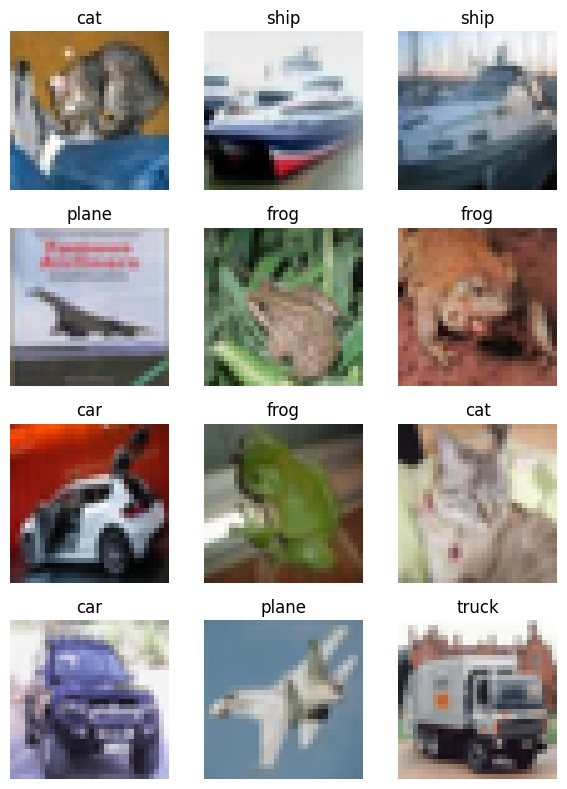

In [18]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

def unpickle(file_path):
    with open(file_path, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

data_dir = "./cifar-10-batches-py"
test_batch_path = os.path.join(data_dir, "test_batch")
data_dict = unpickle(test_batch_path)

test_raw_images = data_dict[b'data']
print(f'there are {test_raw_images.shape[0]} images, each image has {test_raw_images.shape[1]} features (32x32x3)')
labels = data_dict[b'labels']
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(6, 8))
for i in range(12):
    img = test_raw_images[i].reshape(3, 32, 32).transpose(1, 2, 0)
    plt.subplot(4, 3, i + 1)
    plt.imshow(img)
    plt.title(classes[labels[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

17. Write a dataset class for loading CIFAR-10. Make sure it could be transferred to Pytorch Dataloader. The class should meet the following requirements: (1) Inherit pytorch’s DataSet class; (2) Load the image file and save in proper way; (3) Override __getitem__ and __len__ methods.    
Hint: If you find this part a little hard, check the official code and make sure you understand each part.  

In [34]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class MyCIFAR10Dataset(Dataset):
    def __init__(self, file_paths, transform=None, target_transform=None):

        data_list, target_list = [], []
        for file_path in file_paths:
            entry = unpickle(file_path)
            data_list.append(entry[b'data'])
            target_list.extend(entry[b'labels'])
        
        self.data = np.concatenate(data_list, axis=0)
        self.targets = target_list

        self.transform = transform
        self.target_transform = target_transform
        
        # (N, 3072) -> (N, 3, 32, 32) -> (N, 32, 32, 3)
        self.data = self.data.reshape(-1, 3, 32, 32)
        self.data = self.data.transpose((0, 2, 3, 1))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        img = self.data[index]
        target = int(self.targets[index])

        img = Image.fromarray(img)
        if self.transform is not None:
            img = self.transform(img)
        if self.target_transform is not None:
            target = self.target_transform(target)

        return img, target

18. Read 6 and learn how to use torchvision.transforms to transform images.  

In [35]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    # [0, 255] -> [0, 1]
    transforms.ToTensor(),
    # [0, 1] -> [-1, 1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

19. Run one epoch for loading CIFAR-10 with Pytorch Dataloader and test the loading time of different batch_size (1, 4, 64, 1024), different num_workers (0,1,4,16), and whether use pin_memory or not.  

In [ ]:
import time

def test_dataloader_epoch_time(dataset, batch_size, num_workers, pin_memory):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory
    )

    # CPU timing
    cpu_start_time = time.time()
    for images, labels in loader:
        pass
    cpu_end_time = time.time()
    cpu_time = cpu_end_time - cpu_start_time

    # GPU timing
    gpu_time = None
    if torch.cuda.is_available():
        device = torch.device("cuda:0")
        gpu_start_time = time.time()
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

        torch.cuda.synchronize(device)
        gpu_end_time = time.time()
        gpu_time = gpu_end_time - gpu_start_time

    return cpu_time, gpu_time

In [37]:
train_files = [
        os.path.join(data_dir, "data_batch_1"),
        os.path.join(data_dir, "data_batch_2"),
        os.path.join(data_dir, "data_batch_3"),
        os.path.join(data_dir, "data_batch_4"),
        os.path.join(data_dir, "data_batch_5"),
    ]

train_dataset = MyCIFAR10Dataset(
    train_files,
    transform=train_transform
)

batch_sizes = [1, 4, 64, 1024]
num_workers_list = [0, 1, 4, 16]
pin_memory_list = [False, True]

In [41]:
results = []

print(f"{'batch_size':>12} {'num_workers':>12} {'pin_memory':>12} {'cpu_time':>12} {'gpu_time':>12}")
for batch_size in batch_sizes:
    for num_workers in num_workers_list:
        for pin_memory in pin_memory_list:
            cpu_time, gpu_time = test_dataloader_epoch_time(
                dataset=train_dataset,
                batch_size=batch_size,
                num_workers=num_workers,
                pin_memory=pin_memory
            )
            results.append((batch_size, num_workers, pin_memory, cpu_time, gpu_time))
            print(f"{batch_size:12d} {num_workers:12d} {str(pin_memory):>12} {cpu_time:12.2f} {gpu_time:12.2f}")

  batch_size  num_workers   pin_memory     cpu_time     gpu_time
           1            0        False        12.74        15.11
           1            0         True        14.18        19.04
           1            1        False       138.68       130.24
           1            1         True       136.28       140.15
           1            4        False        62.53        63.52
           1            4         True        73.75        74.28
           1           16        False        41.56        74.35
           1           16         True        74.40        90.99
           4            0        False        11.37        10.13
           4            0         True        11.02        11.10
           4            1        False        28.92        29.49
           4            1         True        35.29        34.32
           4            4        False        19.10        14.87
           4            4         True        13.32        18.83
           4           16

20. Calculate the mean and std of CIFAR-10’ training set within each RGB channel. 

In [ ]:
import torch
from torch.utils.data import DataLoader

def get_mean_and_std(dataset):
    dataloader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=16)

    channel_sum = torch.zeros(3)
    channel_sum_sq = torch.zeros(3)
    total_pixels = 0

    for inputs, target in dataloader:
        batch_size, channels, height, width = inputs.shape
        num_pixels = batch_size * height * width

        channel_sum += inputs.sum(dim=[0, 2, 3])
        channel_sum_sq += (inputs ** 2).sum(dim=[0, 2, 3])
        total_pixels += num_pixels

    mean = channel_sum / total_pixels
    std = torch.sqrt(channel_sum_sq / total_pixels - mean ** 2)

    return mean, std

train_dataset_origin = MyCIFAR10Dataset(
    train_files,
    transform=transforms.ToTensor()
)
mean, std = get_mean_and_std(train_dataset_origin)
print(f'the mean {mean*255} and std {std*255} of CIFAR-10')


the mean tensor([125.3070, 122.9505, 113.8655]) and std tensor([62.9931, 62.0885, 66.7047]) of CIFAR-10 training set within each RGB channel


21. Image to character painting  

(a) Target  

Converting the RGB color image to character painting with Python code  

- Character painting is a combination of a series of characters. We can think of characters as relatively large pixels. A character can represent a color. The more types of characters, the more colors can be represented, and the picture will be more hierarchical sense  

(b) Requirements  

- Python 3.5  
- pillow 5.1.0  

(c) Method  

i. Use PIL (pillow) to get the input picture  

ii. Use the following formula to map RGB values to gray values (note that this formula is not a real algorithm, but a simplified sRGB IEC61966-2.1 formula)  

- gray = 0.2126 * r + 0.7152 * g + 0.0722 * b  

iii. Create a character list (length and content are customized)  

iv. Map the gray value to characters and save the result with a string (note the corresponding picture  
size, add line breaks)  

v. Export character painting to a .txt file  

(d) Result  

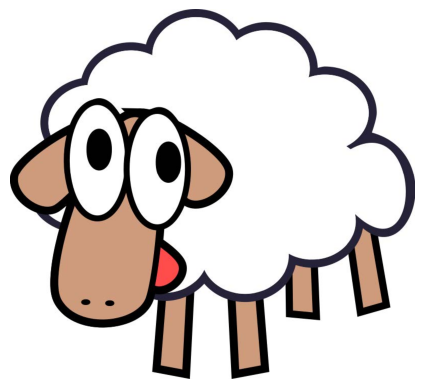

.....................=+++++++=:....:....................
...................-*=:......-*++++++++=................
.............:-====#:..........-......:=*-..............
...........-*+-:::--....................:#-.............
..........++.............................+*++=-:........
.......-=++..................................:-++:......
.....=*=:..:-:..................................-#:.....
....=#...=+--++-+++=+=:..........................=*.....
....#-.:*+....-@*%+:.-*+:........................+=.....
....+#*%#..#%+.+%=.....#%#=:....................+%+=:...
..-*#*=#=.=@@@.:%...=%%=#=*#*:.................--::-++:.
:*#+==-#-.:@@#.-*...%@@##=-=*%-......................=#:
@*=====#=...:..-*...+@@=#===-*%.......................+#
%*====-+#......*%....::.%===+%=.......................-@
:*#*+=*%@+....=##-.....+%**#*:........................-%
..:=%%+##**==**==#-...++.::.....................:.....#=
.....-+@=-=++=====**#+-........................-%+===*=.
......*#-===========@+.........

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

def rgb_to_gray(r, g, b):
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

def image_to_ascii(input_path, output_path, new_width):

    ascii_chars = "@%#*+=-:. "
    img = Image.open(input_path).convert("RGB")

    width, height = img.size
    new_height = int(height * new_width / width * 0.55)
    img = img.resize((new_width, new_height))

    ascii_str = ""
    pixels = img.load()

    for y in range(new_height):
        for x in range(new_width):
            r, g, b = pixels[x, y]
            gray = rgb_to_gray(r, g, b)

            index = int(gray * (len(ascii_chars) - 1) / 255)
            ascii_str += ascii_chars[index]

        ascii_str += "\n"

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(ascii_str)

    return ascii_str

input_image = "sheep.jpg"
output_txt = "ascii_sheep.txt"

img = plt.imread(input_image)
plt.imshow(img)
plt.axis('off')
plt.show()

result = image_to_ascii(input_image, output_txt, new_width=56)
print(result)


22. Numpy exercises  

- Consider a random 10x2 matrix representing cartesian coordinates, convert them to polar coordinates.  
- Create a 2D array subclass such that Z[i, j] == Z[j, i].  
- Consider 2 sets of points P0, P1 describing lines (2d) and a set of points P, how to compute distance from each point j (P[j]) to each line i (P0[i],P1[i])?  

In [10]:
import numpy as np

# cartesian to polar
cartesian = np.random.randn(10, 2)
x, y = cartesian[:, 0], cartesian[:, 1]
r = np.sqrt(x ** 2 + y ** 2)
theta = np.arctan2(y, x)
polar = np.column_stack((r, theta))

print("cartesian")
print(cartesian)
print("polar")
print(polar)

cartesian
[[ 1.32348932 -1.03769628]
 [ 1.74566733  1.29339354]
 [-0.2365882  -0.13512428]
 [-0.55359726  0.54197763]
 [ 0.7272422  -0.650899  ]
 [ 0.40665408  0.42507162]
 [ 0.12376276  0.38757364]
 [ 1.63166586  0.27265984]
 [-0.67327822  1.02001231]
 [ 0.63512882 -0.83856601]]
polar
[[ 1.68179593 -0.66494616]
 [ 2.17260702  0.63766221]
 [ 0.27245651 -2.62266635]
 [ 0.774732    2.36680005]
 [ 0.97598705 -0.73005895]
 [ 0.58826305  0.80753831]
 [ 0.40685445  1.2617039 ]
 [ 1.65429045  0.16557532]
 [ 1.22218193  2.1542172 ]
 [ 1.05194181 -0.92257683]]


In [ ]:
import numpy as np

# a 2D array subclass
class SymmetricArray(np.ndarray):
    def __new__(cls, input_array):
        arr = np.asarray(input_array)
        obj = arr.view(cls)
        return obj

    def __setitem__(self, index, value):
        super().__setitem__(index, value)

        if isinstance(index, tuple) and len(index) == 2:
            i, j = index
            block = np.asarray(super().__getitem__((i, j)))

            if block.ndim >= 2:
                mirror_block = block.T
            else:
                mirror_block = block
            super().__setitem__((j, i), mirror_block)

z = SymmetricArray(np.zeros((4, 4)))
print(z)
z[0, 2] = 5
print(z)
z[1, :] = [1, 2, 3, 4]
print(z)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[0. 0. 5. 0.]
 [0. 0. 0. 0.]
 [5. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[0. 1. 5. 0.]
 [1. 2. 3. 4.]
 [5. 3. 0. 0.]
 [0. 4. 0. 0.]]


In [ ]:
import numpy as np

# compute distance
def point_to_line_distances(P0, P1, P2):
    """
    input:
        P0: shape (n_lines, 2)
        P1: shape (n_lines, 2)
        P : shape (n_points, 2)
    output:
        distances: shape (n_lines, n_points)
        distances[i, j] represents the distance from point P[j] ti line (P0[i], P1[i])
    """
    # shape (n_lines, 2)
    v = P1 - P0
    # shape: (n_lines, n_points, 2)
    w = P[None, :, :] - P0[:, None, :]
    # shape: (n_lines, n_points)
    cross = v[:, None, 0] * w[:, :, 1] - v[:, None, 1] * w[:, :, 0]
    # shape: (n_lines, 1)
    norm_v = np.linalg.norm(v, axis=1, keepdims=True)

    distances = np.abs(cross) / norm_v
    return distances


P0 = np.array([[0, 0],
               [1, 1]])

P1 = np.array([[1, 0],
               [3, 2]])

P = np.array([[1, 2],
              [3, 1],
              [0, 1]])

d = point_to_line_distances(P0, P1, P)
print(d)

[[2.         1.         1.        ]
 [0.89442719 0.89442719 0.4472136 ]]


23. Bilinear Interpolation  
Please implement the bilinear interpolation algorithm using python. Check this for an introduction to bilinear  
interpolation.  
Test samples:  
A =  
((110, 120, 130),  
(210, 220, 230),  
(310, 320, 330))  
BilinearInterpolation(A, (1, 1)) == 110  
BilinearInterpolation(A, (2.5, 2.5)) == 275  

In [21]:
import numpy as np

def BilinearInterpolation(A, point):

    A = np.asarray(A, dtype=float)
    x, y = point
    rows, cols = A.shape

    if not (1 <= x <= cols and 1 <= y <= rows):
        raise ValueError("out of scope")

    x -= 1
    y -= 1
    x0 = int(np.floor(x))
    x1 = int(np.ceil(x))
    y0 = int(np.floor(y))
    y1 = int(np.ceil(y))

    if x0 == x1 and y0 == y1:
        return A[y0, x0]
    if x0 == x1:
        return A[y0, x0] * (y1 - y) + A[y1, x0] * (y - y0)
    if y0 == y1:
        return A[y0, x0] * (x1 - x) + A[y0, x1] * (x - x0)
    Q11 = A[y0, x0]
    Q21 = A[y0, x1]
    Q12 = A[y1, x0]
    Q22 = A[y1, x1]

    R1 = Q11 * (x1 - x) + Q21 * (x - x0)
    R2 = Q12 * (x1 - x) + Q22 * (x - x0)
    P = R1 * (y1 - y) + R2 * (y - y0)

    return P


A = np.array([
    [110, 120, 130],
    [210, 220, 230],
    [310, 320, 330]
])

print(f"expect: 110, output: {BilinearInterpolation(A, (1, 1))}")      
print(f"expect: 275, output: {BilinearInterpolation(A, (2.5, 2.5))}")  

expect: 110, output: 110.0
expect: 275, output: 275.0


24. Cartesian product  
Given an arbitrary number of vectors, build the cartesian product (every combinations of every item).  
e.g. [1, 2, 3], [4, 5], [6, 7] ==> [[1 4 6] [1 4 7] [1 5 6] [1 5 7] [2 4 6] [2 4 7] [2 5 6] [2 5 7] [3 4 6] [3 4 7] [3 5 6] [3 5 7]]  

In [ ]:
import numpy as np

def cartesian_product(*arrays):
    arrays = [np.asarray(array) for array in arrays]
    grids = np.meshgrid(*arrays, indexing='ij')
    result = np.stack(grids, axis=-1).reshape(-1, len(arrays))
    return result


result = cartesian_product([1, 2, 3], [4, 5], [6, 7])
print(result)

[[1 4 6]
 [1 4 7]
 [1 5 6]
 [1 5 7]
 [2 4 6]
 [2 4 7]
 [2 5 6]
 [2 5 7]
 [3 4 6]
 [3 4 7]
 [3 5 6]
 [3 5 7]]


25. Extracting a subpart of an array  
Consider an arbitrary array, write a function that extract a subpart with a fixed shape and centered on a given element (pad with a fill value when necessary)  
e.g.  
In:  
\>\> Z = np.random.randint(0, 10, (5, 5))  
\>\> shape = (4, 4)  
\>\> fill = 0  
\>\> position = (1,1)  
\>\> Z  
[[3 6 8 5 9]  
[4 9 0 0 9]  
[6 1 4 0 8]  
[9 1 2 0 9]  
[4 1 7 5 0]]  
Out:  
[[0 0 0 0]  
[0 3 6 8]  
[0 4 9 0]  
[0 6 1 4]]  

In [27]:
import numpy as np

def extract_subpart(Z, shape, position, fill=0):

    Z = np.asarray(Z)
    rows, cols = Z.shape
    h, w = shape
    r, c = position
    result = np.full((h, w), fill, dtype=Z.dtype)

    r0 = r - h // 2
    c0 = c - w // 2
    r1 = r0 + h
    c1 = c0 + w

    origin_r0 = max(r0, 0)
    origin_c0 = max(c0, 0)
    origin_r1 = min(r1, rows)
    origin_c1 = min(c1, cols)

    target_r0 = origin_r0 - r0
    target_c0 = origin_c0 - c0
    target_r1 = target_r0 + (origin_r1 - origin_r0)
    target_c1 = target_c0 + (origin_c1 - origin_c0)

    result[target_r0: target_r1, target_c0: target_c1] = Z[origin_r0: origin_r1, origin_c0: origin_c1]

    return result


Z = np.array([
    [3, 6, 8, 5, 9],
    [4, 9, 0, 0, 9],
    [6, 1, 4, 0, 8],
    [9, 1, 2, 0, 9],
    [4, 1, 7, 5, 0]
])
shape = (4, 4)
fill = 0
position = (1, 1)

print(extract_subpart(Z, shape, position, fill))

[[0 0 0 0]
 [0 3 6 8]
 [0 4 9 0]
 [0 6 1 4]]


26. Matrix operations  

Please implement following matrix (just 2D) operations without numpy:  

- add  
- subtract  
- scalar multiply  
- multiply  
- identity  
- transpose  
- inverse  

Test samples:  
In:  
\>\> matrix_a = [[12, 10], [3, 9]]  
\>\> matrix_b = [[3, 4], [7, 4]]  
\>\> matrix_c = [[11, 12, 13, 14], [21, 22, 23, 24], [31, 32, 33, 34], [41, 42, 43, 44]]  
\>\> matrix_d = [[3, 0, 2], [2, 0, -2], [0, 1, 1]]  
Out:  
add(matrix_a, matrix_b) == [[15, 14], [10, 13]]  
subtract(matrix_a, matrix_b) == [[9, 6], [-4, 5]]  
scalar_multiply(matrix_b, 3) == [[9, 12], [21, 12]]  
multiply(matrix_a, matrix_b) == [[106, 88], [72, 48]]  
identity(3) == [[1, 0, 0], [0, 1, 0], [0, 0, 1]]  
transpose(matrix_c) == [[11, 21, 31, 41], [12, 22, 32, 42], [13, 23, 33, 43], [14, 24, 34, 44]]  
inverse(matrix_d) == [[0.2, 0.2, 0.0], [-0.2, 0.30000000000000004, 1.0], [0.2, -0.30000000000000004, 0.0]]  

In [30]:
def shape(matrix):
    return len(matrix), len(matrix[0])

def add(A, B):

    rows, cols = shape(A)
    result = []
    for i in range(rows):
        row = []
        for j in range(cols):
            row.append(A[i][j] + B[i][j])
        result.append(row)
    return result


def subtract(A, B):

    rows, cols = shape(A)
    result = []
    for i in range(rows):
        row = []
        for j in range(cols):
            row.append(A[i][j] - B[i][j])
        result.append(row)
    return result


def scalar_multiply(A, k):

    rows, cols = shape(A)
    result = []
    for i in range(rows):
        row = []
        for j in range(cols):
            row.append(A[i][j] * k)
        result.append(row)
    return result


def multiply(A, B):

    rows_a, cols_a = shape(A)
    rows_b, cols_b = shape(B)

    result = []
    for i in range(rows_a):
        row = []
        for j in range(cols_b):
            s = 0
            for k in range(cols_a):
                s += A[i][k] * B[k][j]
            row.append(s)
        result.append(row)
    return result


def identity(n):

    result = []
    for i in range(n):
        row = []
        for j in range(n):
            if i == j:
                row.append(1)
            else:
                row.append(0)
        result.append(row)
    return result


def transpose(A):

    rows, cols = shape(A)
    result = []
    for j in range(cols):
        row = []
        for i in range(rows):
            row.append(A[i][j])
        result.append(row)
    return result


def inverse(A):

    n, m = shape(A)
    # [A | I]
    aug = []
    I = identity(n)
    for i in range(n):
        aug.append([float(x) for x in A[i]] + [float(x) for x in I[i]])

    for row in range(n):
        pivot_col = row
        while pivot_col < n and aug[row][pivot_col] == 0:
            pivot_col += 1

        if pivot_col == n:
            continue

        pivot = aug[row][pivot_col]
        for j in range(2 * n):
            aug[row][j] /= pivot

        for i in range(n):
            if i != row and aug[i][pivot_col] != 0:
                factor = aug[i][pivot_col]
                for j in range(2 * n):
                    aug[i][j] -= factor * aug[row][j]

    result = []
    for i in range(n):
        result.append(aug[i][n:])
    return result

matrix_a = [[12, 10], [3, 9]]
matrix_b = [[3, 4], [7, 4]]
matrix_c = [[11, 12, 13, 14], [21, 22, 23, 24], [31, 32, 33, 34], [41, 42, 43, 44]]
matrix_d = [[3, 0, 2], [2, 0, -2], [0, 1, 1]]

print("add(matrix_a, matrix_b) =", add(matrix_a, matrix_b))
print("subtract(matrix_a, matrix_b) =", subtract(matrix_a, matrix_b))
print("scalar_multiply(matrix_b, 3) =", scalar_multiply(matrix_b, 3))
print("multiply(matrix_a, matrix_b) =", multiply(matrix_a, matrix_b))
print("identity(3) =", identity(3))
print("transpose(matrix_c) =", transpose(matrix_c))
print("inverse(matrix_d) =", inverse(matrix_d))

add(matrix_a, matrix_b) = [[15, 14], [10, 13]]
subtract(matrix_a, matrix_b) = [[9, 6], [-4, 5]]
scalar_multiply(matrix_b, 3) = [[9, 12], [21, 12]]
multiply(matrix_a, matrix_b) = [[106, 88], [72, 48]]
identity(3) = [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
transpose(matrix_c) = [[11, 21, 31, 41], [12, 22, 32, 42], [13, 23, 33, 43], [14, 24, 34, 44]]
inverse(matrix_d) = [[0.19999999999999998, 0.2, 0.0], [0.2, -0.30000000000000004, -0.0], [-0.2, 0.30000000000000004, 1.0]]


27. Greatest common divisor  
Find the greatest common divisor(gcd) of two integers.  
Test samples:  
- GCD(3, 5) = 1  
- GCD(6, 3) = 3  
- GCD(-2, 6) = 2  
- GCD(0, 3) = 3  

In [32]:
def GCD(a, b):
    a, b = abs(a), abs(b)
    while b != 0:
        a, b = b, a % b
    return a 
 
print(f"expect: 1, output: {GCD(3, 5)}")   
print(f"expect: 3, output: {GCD(6, 3)}")   
print(f"expect: 2, output: {GCD(-2, 6)}")   
print(f"expect: 3, output: {GCD(0, 3)}")      

expect: 1, output: 1
expect: 3, output: 3
expect: 2, output: 2
expect: 3, output: 3


28. How many ways are there to densely tile a 2 x n floor using 1 x 2 and 2 x 2 tiles  

In [37]:
def ways(n):
    if n == 0: return 1
    if n == 1: return 1
    return ways(n-1) + 2 * ways(n-2)

for i in range(1, 11):
    expect = (2 ** (i + 1) + (-1) ** i) / 3
    print(f"expect: {int(expect)}, output: {ways(i)}")

expect: 1, output: 1
expect: 3, output: 3
expect: 5, output: 5
expect: 11, output: 11
expect: 21, output: 21
expect: 43, output: 43
expect: 85, output: 85
expect: 171, output: 171
expect: 341, output: 341
expect: 683, output: 683


29. Password checking  

A website requires the users to input username and password to register. Write a program to check the validity  
of password input by users. Following are the criteria for checking the password:  

- At least 1 letter between [a-z]  
- At least 1 number between [0-9]  
- At least 1 letter between [A-Z]  
- At least 1 character from [$#@]  
- Minimum length of transaction password: 6  
- Maximum length of transaction password: 12  

Your program should accept a sequence of comma separated passwords and will check them according to the above criteria. Passwords that match the criteria are to be printed, each separated by a comma.  

e.g.  
If the following passwords are given as input to the program: ABd1234@1,a F1#,2w3E*,2We3345  
Then, the output of the program should be: ABd1234@1

In [ ]:
import re

def check_passwords(str):
    passwords = str.split(',')
    valid = []

    for password in passwords:
        if (
            6 <= len(password) <= 12
            and re.search(r"[a-z]", password)
            and re.search(r"[A-Z]", password)
            and re.search(r"[0-9]", password)
            and re.search(r"[$#@]", password)
        ):
            valid.append(password)

    return ",".join(valid)

s = "ABd1234@1,a F1#,2w3E*,2We3345"
print(check_passwords(s))

ABd1234@1
